# EWMA Optimizer (Exponential Weighted Moving Average)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)

d:\Programming\Deep_Learning\.deeplr\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\sande\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3


In [3]:
import os

print("File name of directory:",os.listdir(path))

File name of directory: ['DailyDelhiClimateTest.csv', 'DailyDelhiClimateTrain.csv']


In [4]:
# Load the datsets

df=pd.read_csv(os.path.join(path,"DailyDelhiClimateTrain.csv"))
df.head()


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
df=df[['date', 'meantemp']]
df.head()


,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


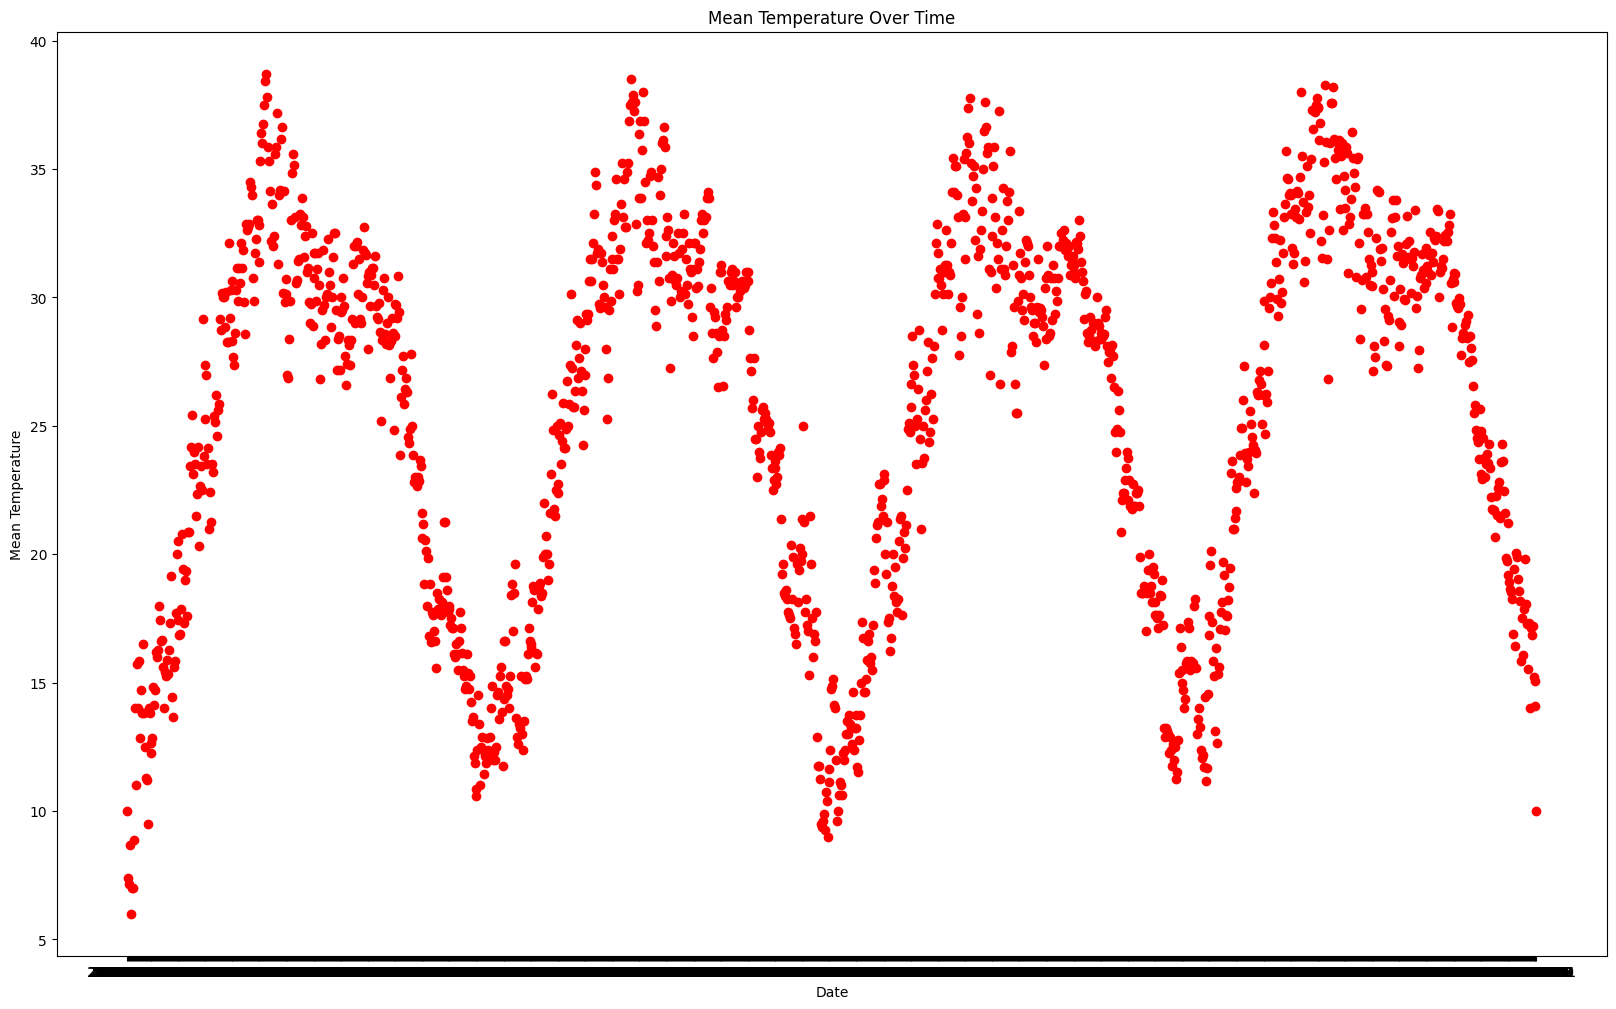

In [10]:
plt.figure(figsize=(20,12))  
plt.scatter(df['date'], df['meantemp'],color='red')
plt.title('Mean Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.show()

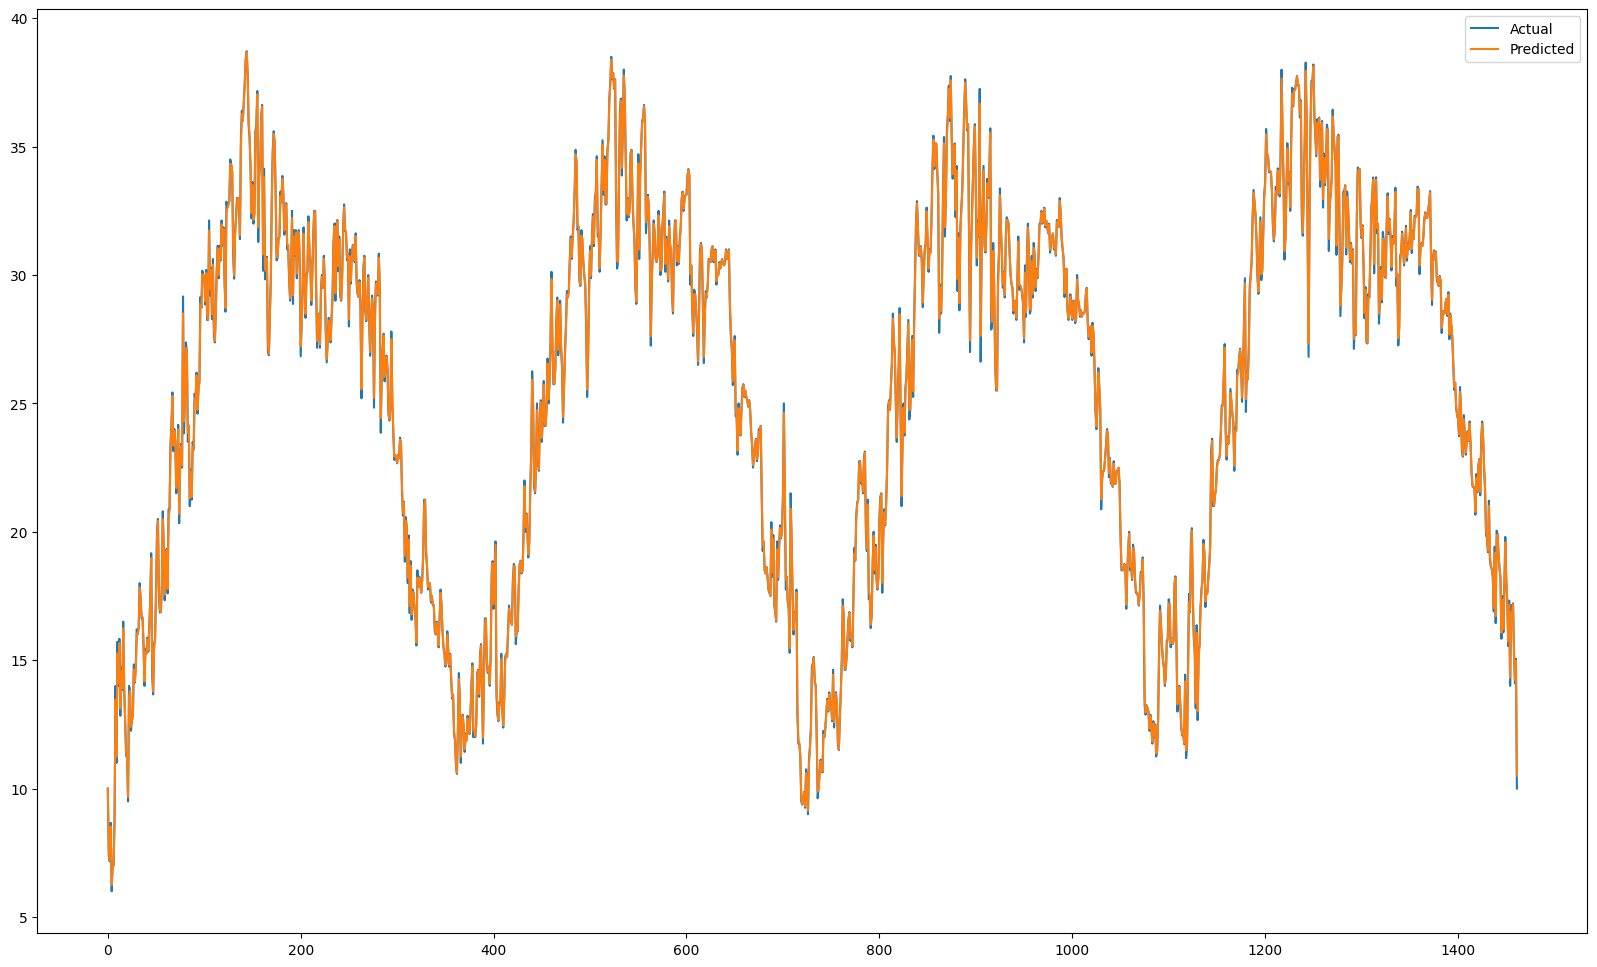

In [11]:
x1=df['meantemp'].ewm(alpha=0.9).mean()
plt.figure(figsize=(20,12))
plt.plot(df['meantemp'],label='Actual')
plt.plot(x1,label='Predicted')
plt.legend()
plt.show()

In [13]:
df['mean_ewm']=x1
df.head()

,date,meantemp,mean_ewm
0,2013-01-01,10.000000,10.000000
1,2013-01-02,7.400000,7.636364
2,2013-01-03,7.166667,7.213213
3,2013-01-04,8.666667,8.521452
4,2013-01-05,6.000000,6.252123


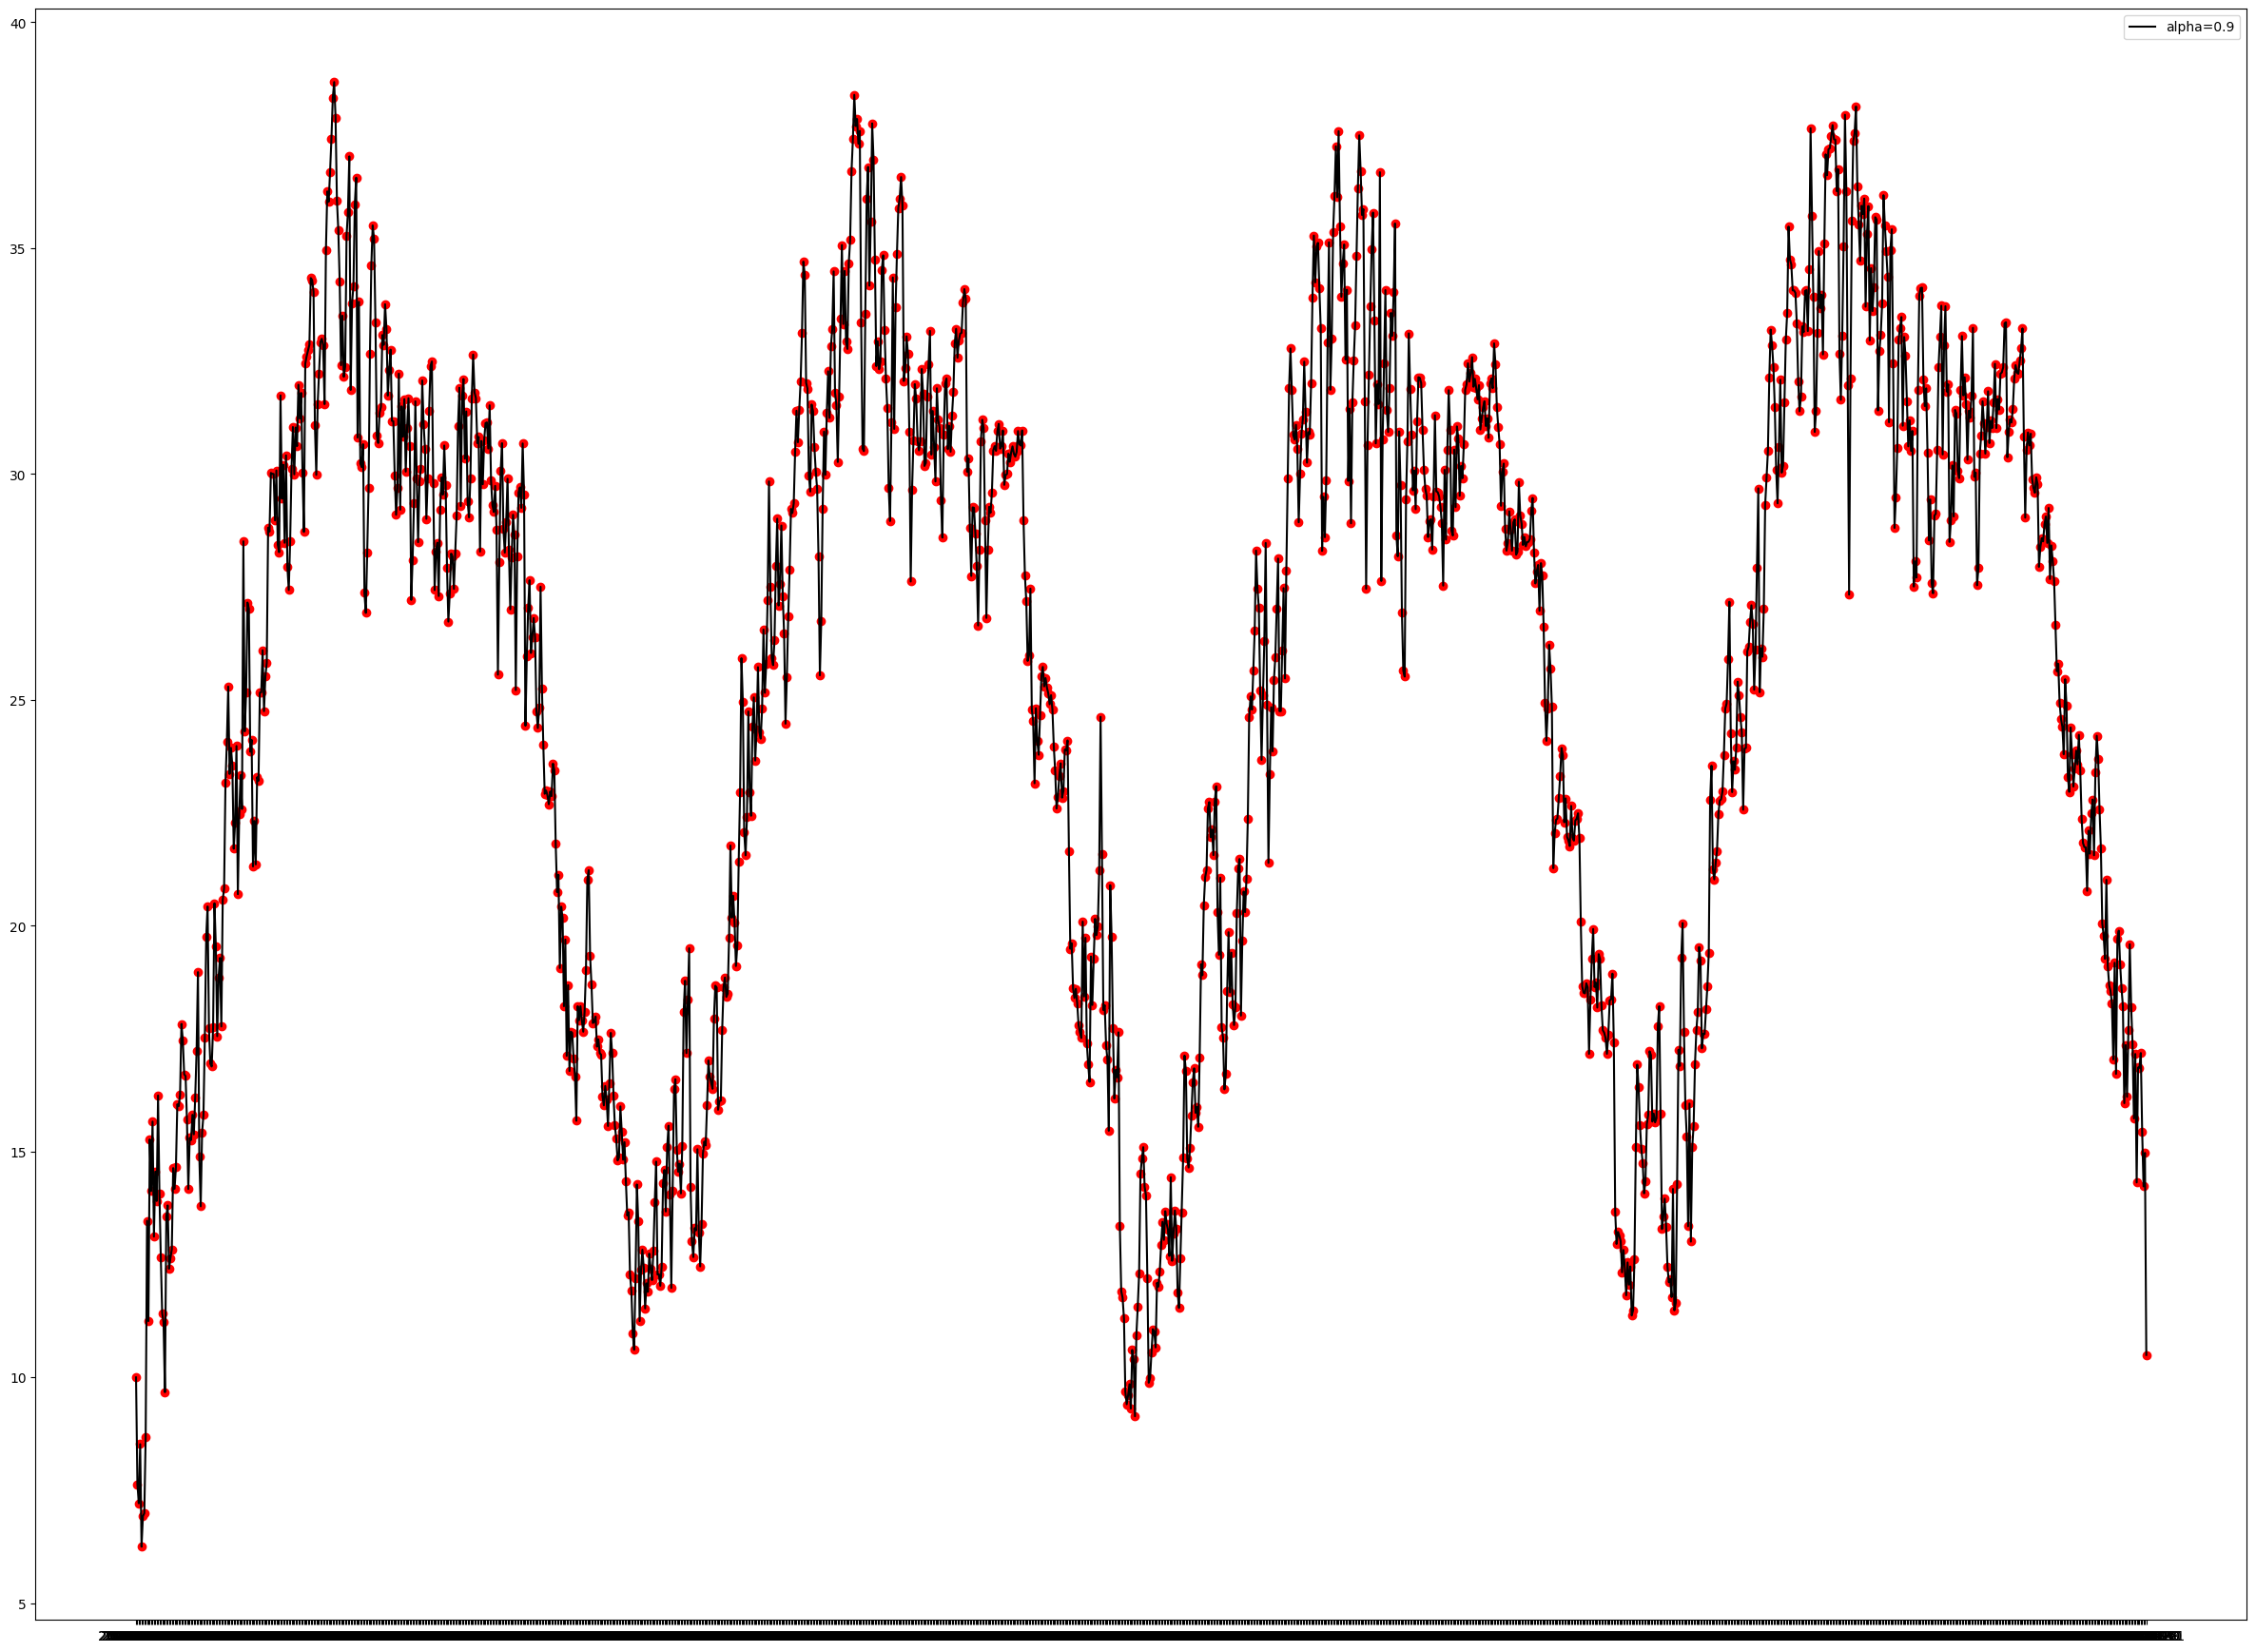

In [15]:
plt.figure(figsize=(30,22))
plt.scatter(df['date'],df['mean_ewm'],color='red')
plt.plot(df['date'],x1,color='black',label='alpha=0.9')
plt.legend()
plt.show()


## change EWM values

In [21]:
X2=df['meantemp'].ewm(alpha=0.5).mean()

In [22]:
df['mean_ewm_0.5']=X2

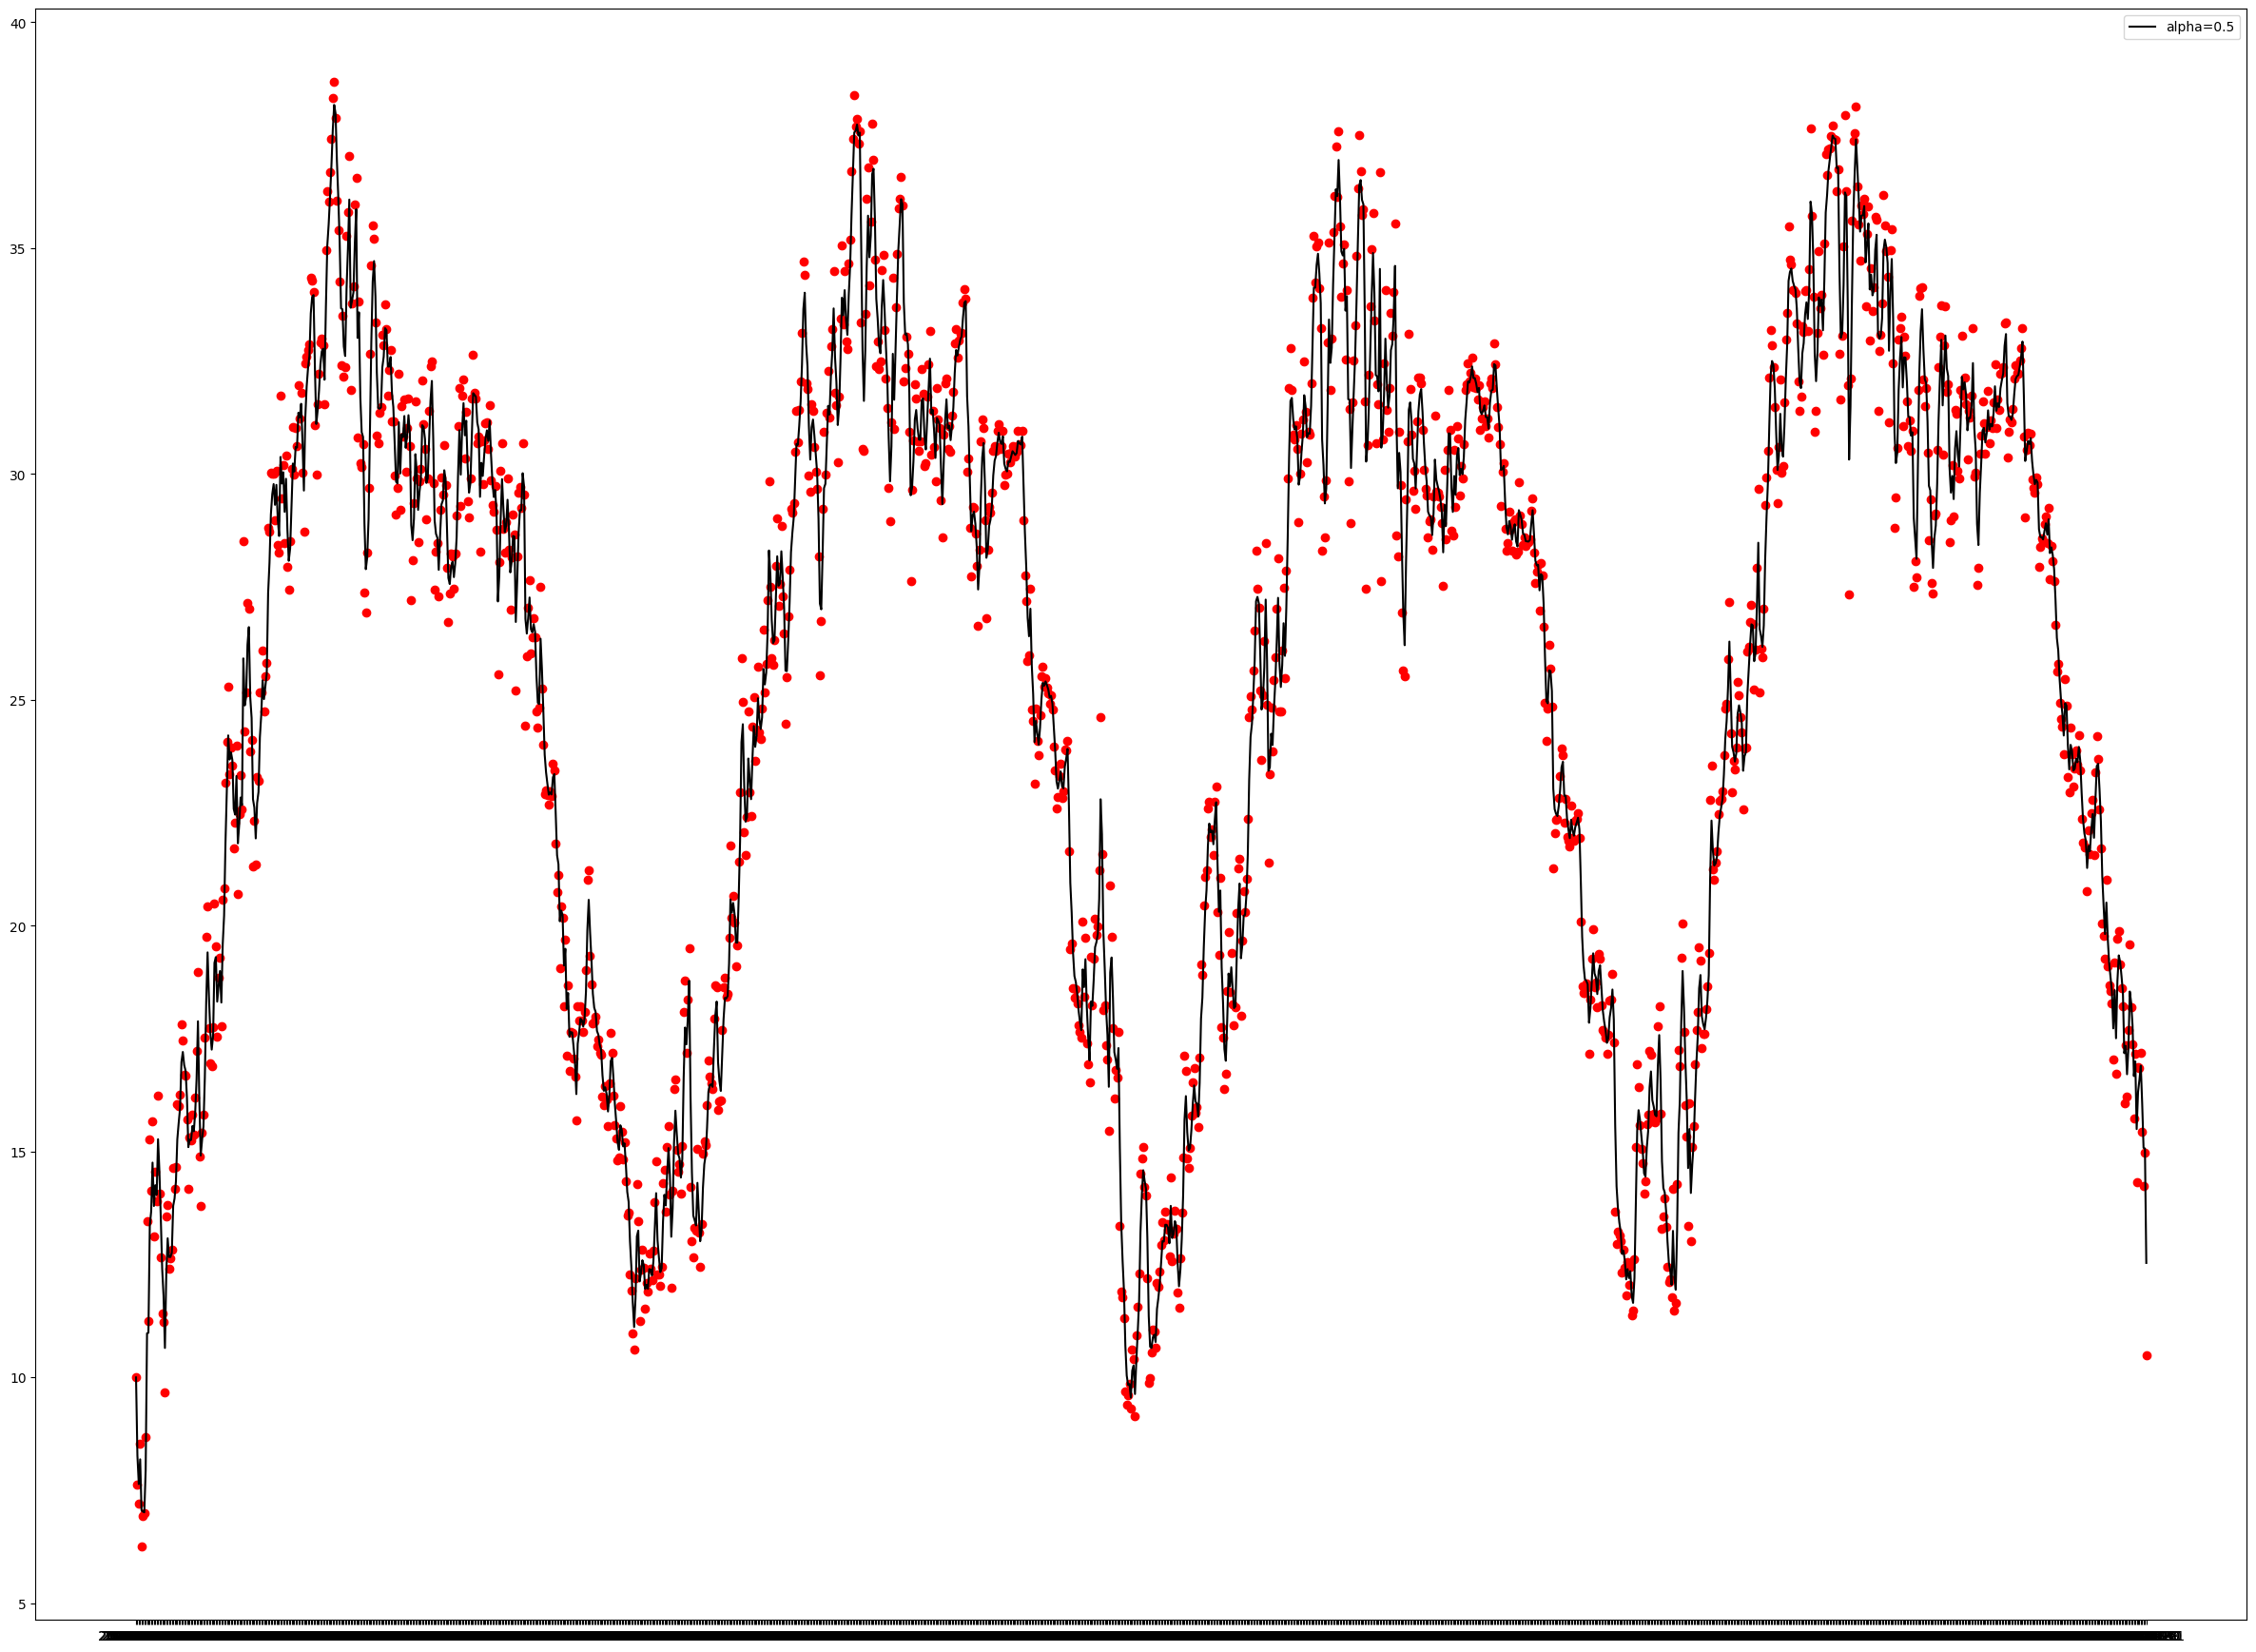

In [23]:
plt.figure(figsize=(30,22))
plt.scatter(df['date'],df['mean_ewm'],color='red')
plt.plot(df['date'],x2,color='black',label='alpha=0.5')
plt.legend()
plt.show()
